In [ ]:
# =====================================================
# T5 ABSTRACTIVE SUMMARISATION WITH CHECKPOINTING
# IMDB DATASET
# SAFE VERSION FOR LONG COLAB RUNS
# =====================================================

!pip install -q pandas numpy nltk transformers sentencepiece accelerate tqdm rouge-score

import re
import os
import time
import numpy as np
import pandas as pd
import nltk
import torch

from tqdm import tqdm
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer

nltk.download("punkt")
nltk.download("punkt_tab")

print("Torch version:", torch.__version__)

# -------------------------
# LOAD DATASET
# -------------------------
DATA_PATH = "/content/IMDB Dataset.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())

# -------------------------
# CLEAN TEXT
# -------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df = df.dropna(subset=["review", "sentiment"]).drop_duplicates().reset_index(drop=True)
df["clean_text"] = df["review"].apply(clean_text)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

print("Cleaned dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())

# -------------------------
# SPLIT DATASET
# -------------------------
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

train_texts = train_texts.tolist()
val_texts = val_texts.tolist()
test_texts = test_texts.tolist()

train_labels = train_labels.tolist()
val_labels = val_labels.tolist()
test_labels = test_labels.tolist()

print("Train:", len(train_texts))
print("Val:", len(val_texts))
print("Test:", len(test_texts))

# -------------------------
# LOAD T5 MODEL
# -------------------------
# Good practical choice:
MODEL_NAME = "t5-small"

# Alternatives:
# MODEL_NAME = "t5-base"
# MODEL_NAME = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print("Running on:", device)

# -------------------------
# BATCH SIZE
# -------------------------
BATCH_SIZE = 16 if device.type == "cuda" else 4
print("Batch size:", BATCH_SIZE)

# -------------------------
# GENERATE ONE BATCH
# -------------------------
def generate_summary_batch(text_batch):
    # T5 works best with task prefix
    prefixed_batch = [f"summarize: {str(t).strip()}" for t in text_batch]

    inputs = tokenizer(
        prefixed_batch,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        summary_ids = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=80,
            min_length=20,
            num_beams=2,
            length_penalty=2.0,
            early_stopping=True
        )

    summaries = tokenizer.batch_decode(summary_ids, skip_special_tokens=True)
    return [s.strip() for s in summaries]

# -------------------------
# CHECKPOINT SUMMARISATION
# -------------------------
def summarise_with_checkpoint(texts, labels, save_path, batch_size=BATCH_SIZE):
    if os.path.exists(save_path):
        existing_df = pd.read_csv(save_path)
        completed = len(existing_df)
        summaries = existing_df["summary_text"].tolist()
        print(f"Resuming from checkpoint: {completed}")
    else:
        completed = 0
        summaries = []

    start_time = time.time()

    for start_idx in tqdm(range(completed, len(texts), batch_size), desc=f"Summarising {os.path.basename(save_path)}"):
        end_idx = min(start_idx + batch_size, len(texts))

        batch_texts = texts[start_idx:end_idx]
        batch_summaries = generate_summary_batch(batch_texts)
        summaries.extend(batch_summaries)

        temp_df = pd.DataFrame({
            "original_text": texts[:len(summaries)],
            "summary_text": summaries,
            "label": labels[:len(summaries)]
        })

        temp_df.to_csv(save_path, index=False)

    elapsed = time.time() - start_time

    assert len(texts) == len(labels) == len(summaries), "Length mismatch after summarisation"

    print(f"Finished {save_path}")
    print("Rows saved:", len(summaries))
    print("Elapsed minutes:", round(elapsed / 60, 2))

    return summaries, elapsed

# -------------------------
# RUN TRAIN
# -------------------------
train_summaries, train_time = summarise_with_checkpoint(
    train_texts,
    train_labels,
    "/content/train_t5_abstractive_summary.csv"
)

# -------------------------
# RUN VALIDATION
# -------------------------
val_summaries, val_time = summarise_with_checkpoint(
    val_texts,
    val_labels,
    "/content/val_t5_abstractive_summary.csv"
)

# -------------------------
# RUN TEST
# -------------------------
test_summaries, test_time = summarise_with_checkpoint(
    test_texts,
    test_labels,
    "/content/test_t5_abstractive_summary.csv"
)

total_time = train_time + val_time + test_time

print("\nAll summarisation complete")
print("Total time (hours):", round(total_time / 3600, 2))

# -------------------------
# EVALUATION ON TRAIN SPLIT
# -------------------------
original_word_counts = [len(word_tokenize(t)) for t in train_texts]
summary_word_counts = [len(word_tokenize(t)) for t in train_summaries]

original_sentence_counts = [len(sent_tokenize(t)) for t in train_texts]
summary_sentence_counts = [len(sent_tokenize(t)) for t in train_summaries]

avg_original_words = np.mean(original_word_counts)
avg_summary_words = np.mean(summary_word_counts)
avg_original_sentences = np.mean(original_sentence_counts)
avg_summary_sentences = np.mean(summary_sentence_counts)

word_compression_ratio = avg_summary_words / avg_original_words if avg_original_words > 0 else np.nan
sentence_compression_ratio = avg_summary_sentences / avg_original_sentences if avg_original_sentences > 0 else np.nan

print("\n=== SUMMARY COMPRESSION ===")
print("Average original words:", round(avg_original_words, 2))
print("Average summary words:", round(avg_summary_words, 2))
print("Average original sentences:", round(avg_original_sentences, 2))
print("Average summary sentences:", round(avg_summary_sentences, 2))
print("Word compression ratio:", round(word_compression_ratio, 4))
print("Sentence compression ratio:", round(sentence_compression_ratio, 4))

# -------------------------
# ROUGE + BLEU ON TRAIN
# -------------------------
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smoothie = SmoothingFunction().method1

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []
bleu_scores = []

for i in tqdm(range(len(train_texts)), desc="ROUGE/BLEU evaluation"):
    reference = " ".join(sent_tokenize(train_texts[i])[:2])
    generated = train_summaries[i]

    try:
        scores = scorer.score(reference, generated)
        rouge1_scores.append(scores["rouge1"].fmeasure)
        rouge2_scores.append(scores["rouge2"].fmeasure)
        rougeL_scores.append(scores["rougeL"].fmeasure)
    except Exception:
        rouge1_scores.append(np.nan)
        rouge2_scores.append(np.nan)
        rougeL_scores.append(np.nan)

    try:
        bleu_scores.append(
            sentence_bleu([reference.split()], generated.split(), smoothing_function=smoothie)
        )
    except Exception:
        bleu_scores.append(np.nan)

print("\n=== SUMMARY QUALITY ===")
print("Average ROUGE-1:", round(np.nanmean(rouge1_scores), 4))
print("Average ROUGE-2:", round(np.nanmean(rouge2_scores), 4))
print("Average ROUGE-L:", round(np.nanmean(rougeL_scores), 4))
print("Average BLEU:", round(np.nanmean(bleu_scores), 4))

# -------------------------
# SAVE EVALUATION RESULTS
# -------------------------
summary_eval_df = pd.DataFrame({
    "Metric": [
        "Train Summary Time (sec)",
        "Val Summary Time (sec)",
        "Test Summary Time (sec)",
        "Total Summary Time (sec)",
        "Total Summary Time (hr)",
        "Average Original Words",
        "Average Summary Words",
        "Average Original Sentences",
        "Average Summary Sentences",
        "Word Compression Ratio",
        "Sentence Compression Ratio",
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BLEU"
    ],
    "Value": [
        round(train_time, 2),
        round(val_time, 2),
        round(test_time, 2),
        round(total_time, 2),
        round(total_time / 3600, 2),
        round(avg_original_words, 2),
        round(avg_summary_words, 2),
        round(avg_original_sentences, 2),
        round(avg_summary_sentences, 2),
        round(word_compression_ratio, 4),
        round(sentence_compression_ratio, 4),
        round(np.nanmean(rouge1_scores), 4),
        round(np.nanmean(rouge2_scores), 4),
        round(np.nanmean(rougeL_scores), 4),
        round(np.nanmean(bleu_scores), 4)
    ]
})

summary_eval_df.to_csv("/content/t5_abstractive_summary_eval.csv", index=False)
display(summary_eval_df)

print("\nEvaluation results saved")

  Preparing metadata (setup.py) ... done


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Torch version: 2.10.0+cu128
Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Cleaned dataset shape: (49582, 4)

Label distribution:
label
1    24884
0    24698
Name: count, dtype: int64
Train: 34707
Val: 7437
Test: 7438


...

Finished /content/test_t5_abstractive_summary.csv
Rows saved: 7438
Elapsed minutes: 12.04

All summarisation complete
Total time (hours): 1.73

=== SUMMARY COMPRESSION ===
Average original words: 265.46
Average summary words: 39.97
Average original sentences: 12.37
Average summary sentences: 2.52
Word compression ratio: 0.1506
Sentence compression ratio: 0.2035


ROUGE/BLEU evaluation: 100%|██████████| 34707/34707 [01:08<00:00, 508.08it/s]


=== SUMMARY QUALITY ===
Average ROUGE-1: 0.3634
Average ROUGE-2: 0.2365
Average ROUGE-L: 0.3102
Average BLEU: 0.1562


,Metric,Value
0,Train Summary Time (sec),4784.1800
1,Val Summary Time (sec),713.6300
2,Test Summary Time (sec),722.2200
3,Total Summary Time (sec),6220.0300
4,Total Summary Time (hr),1.7300
5,Average Original Words,265.4600
6,Average Summary Words,39.9700
7,Average Original Sentences,12.3700
8,Average Summary Sentences,2.5200
9,Word Compression Ratio,0.1506



Evaluation results saved


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

destination = "/content/drive/MyDrive/MSc_Project/t5_summaries"
os.makedirs(destination, exist_ok=True)

for file in os.listdir("/content"):
    if file.endswith(".csv"):
        shutil.copy(os.path.join("/content", file), destination)

print("All CSV files copied to Google Drive.")
print("Saved in:", destination)

All CSV files copied to Google Drive.
Saved in: /content/drive/MyDrive/MSc_Project/t5_summaries


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: Tesla T4
Reading files from: /content/drive/MyDrive/MSc_Project/t5_summaries

Checking files...
/content/drive/MyDrive/MSc_Project/t5_summaries/train_t5_abstractive_summary.csv -> True
/content/drive/MyDrive/MSc_Project/t5_summaries/val_t5_abstractive_summary.csv -> True
/content/drive/MyDrive/MSc_Project/t5_summaries/test_t5_abstractive_summary.csv -> True

Train shape: (34707, 3)
Validation shape: (7437, 3)
Test shape: (7438, 3)

RUNNING: BERT | Summarised Text | T5


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.434574,0.383315,0.828560,0.793970,0.889068,0.838832,0.914556
2,0.299052,0.529418,0.836090,0.827640,0.850482,0.838906,0.916360


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.8317
Precision: 0.8245
Recall: 0.8444
F1: 0.8343
ROC-AUC: 0.9121
Training time (min): 11.69
Training time per epoch (min): 5.85
Inference time (sec): 15.09
Inference latency per sample (ms): 2.0286
Training throughput (samples/sec): 49.48
Inference throughput (samples/sec): 492.96
Peak training GPU memory (MB): 2205.19
Peak inference GPU memory (MB): 1722.36

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83      3705
    Positive       0.82      0.84      0.83      3733

    accuracy                           0.83      7438
   macro avg       0.83      0.83      0.83      7438
weighted avg       0.83      0.83      0.83      7438



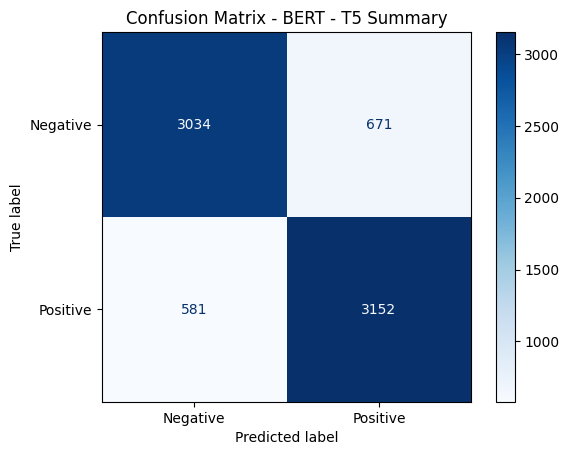

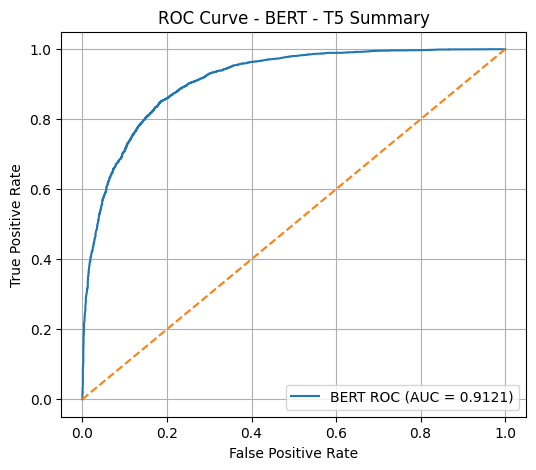

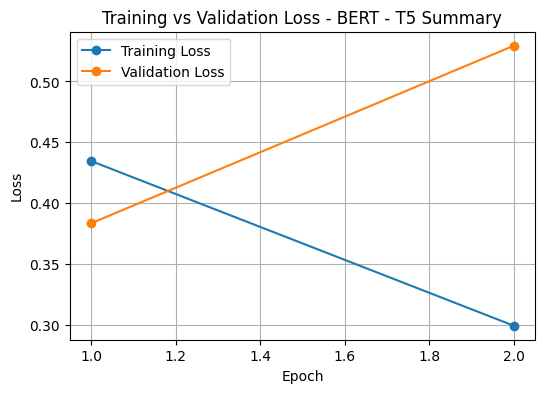


RUNNING: XLNet | Summarised Text | T5


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 48.19
Train avg tokens after trunc: 48.19
Train truncation %: 0.0
Validation avg tokens after trunc: 48.09
Test avg tokens after trunc: 48.19
Test truncation %: 0.0


...

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.430305,0.371945,0.835552,0.799046,0.898178,0.845717,0.920764
2,0.321608,0.524489,0.841334,0.836853,0.849411,0.843085,0.924719


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.8341
Precision: 0.7962
Recall: 0.8998
F1: 0.8448
ROC-AUC: 0.9188
Training time (min): 15.48
Training time per epoch (min): 7.74
Inference time (sec): 23.96
Inference latency per sample (ms): 3.221
Training throughput (samples/sec): 37.37
Inference throughput (samples/sec): 310.46
Peak training GPU memory (MB): 2673.06
Peak inference GPU memory (MB): 1862.2

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.88      0.77      0.82      3705
    Positive       0.80      0.90      0.84      3733

    accuracy                           0.83      7438
   macro avg       0.84      0.83      0.83      7438
weighted avg       0.84      0.83      0.83      7438



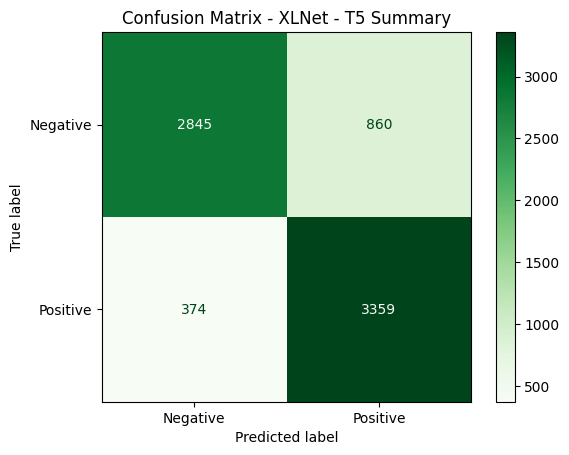

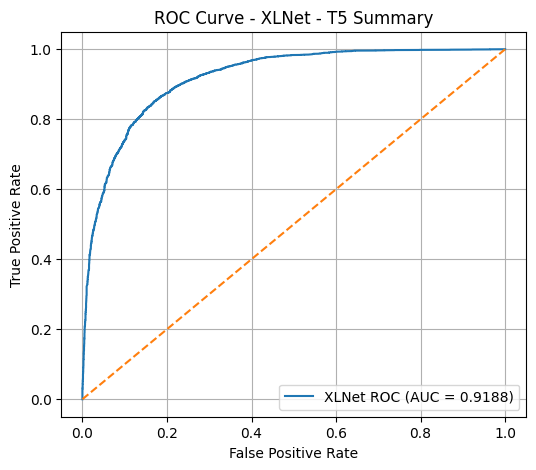

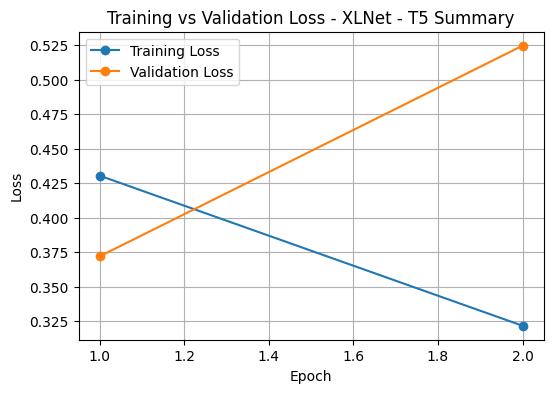


FINAL T5 CLASSIFICATION RESULTS


,Input Type,Summary Method,Summary Length,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train Samples,...,Test Truncation %,Training Time (min),Training Time per Epoch (min),Inference Time (sec),Inference Latency per Sample (ms),Training Throughput (samples/sec),Inference Throughput (samples/sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,T5,Single Abstractive Summary,BERT,0.8317,0.8245,0.8444,0.8343,0.9121,34707,...,0.0,11.69,5.85,15.09,2.0286,49.48,492.96,2205.19,1722.36,Tesla T4
1,Summarised Text,T5,Single Abstractive Summary,XLNet,0.8341,0.7962,0.8998,0.8448,0.9188,34707,...,0.0,15.48,7.74,23.96,3.2210,37.37,310.46,2673.06,1862.20,Tesla T4



Saved: /content/drive/MyDrive/MSc_Project/t5_summaries/t5_abstractive_classification_results.csv


In [ ]:
# =====================================================
# T5 ABSTRACTIVE SUMMARY CLASSIFICATION
# READ FROM GOOGLE DRIVE
# MODELS: BERT + XLNet
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os
import gc
import time
import random
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

warnings.filterwarnings("ignore")

# -------------------------
# MOUNT GOOGLE DRIVE
# -------------------------
drive.mount('/content/drive')

# -------------------------
# REPRODUCIBILITY
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

# -------------------------
# GOOGLE DRIVE PATH
# -------------------------
BASE_DIR = "/content/drive/MyDrive/MSc_Project/t5_summaries"
print("Reading files from:", BASE_DIR)

TRAIN_PATH = f"{BASE_DIR}/train_t5_abstractive_summary.csv"
VAL_PATH   = f"{BASE_DIR}/val_t5_abstractive_summary.csv"
TEST_PATH  = f"{BASE_DIR}/test_t5_abstractive_summary.csv"

print("\nChecking files...")
print(TRAIN_PATH, "->", os.path.exists(TRAIN_PATH))
print(VAL_PATH, "->", os.path.exists(VAL_PATH))
print(TEST_PATH, "->", os.path.exists(TEST_PATH))

# -------------------------
# LOAD DATA
# -------------------------
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("\nTrain shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_texts = train_df["summary_text"].fillna("").astype(str).tolist()
val_texts = val_df["summary_text"].fillna("").astype(str).tolist()
test_texts = test_df["summary_text"].fillna("").astype(str).tolist()

train_labels = train_df["label"].tolist()
val_labels = val_df["label"].tolist()
test_labels = test_df["label"].tolist()

# -------------------------
# DATASET CLASS
# -------------------------
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# -------------------------
# METRICS FUNCTION
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

# -------------------------
# UTILITIES
# -------------------------
def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None

def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = {
        "avg_tokens_before_trunc": float(np.mean(full_lengths)),
        "avg_tokens_after_trunc": float(np.mean(trunc_lengths)),
        "max_tokens_before_trunc": int(np.max(full_lengths)),
        "truncated_count": int(truncated_count),
        "truncation_pct": float(truncated_count / len(full_lengths) * 100)
    }

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc

def plot_confusion_matrix(y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap=cmap)
    plt.title(title)
    plt.show()

def plot_roc_curve(y_true, y_prob, title, label_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{label_name} (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_train_val_loss(trainer, title):
    history = trainer.state.log_history
    train_loss = []
    val_loss = []
    train_epochs = []
    val_epochs = []

    for log in history:
        if "loss" in log and "epoch" in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# -------------------------
# EXPERIMENT FUNCTION
# -------------------------
def run_experiment(model_name, model_label, output_dir,
                   input_type="Summarised Text",
                   summary_method="T5",
                   summary_length="Single Abstractive Summary",
                   max_length=256,
                   batch_size=8):

    print(f"\n{'='*75}")
    print(f"RUNNING: {model_label} | {input_type} | {summary_method}")
    print(f"{'='*75}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.unk_token

    train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=max_length)
    val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=max_length)
    test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=max_length)

    print("\n=== TOKEN / TRUNCATION STATS ===")
    print("Train avg tokens before trunc:", round(train_stats["avg_tokens_before_trunc"], 2))
    print("Train avg tokens after trunc:", round(train_stats["avg_tokens_after_trunc"], 2))
    print("Train truncation %:", round(train_stats["truncation_pct"], 2))
    print("Validation avg tokens after trunc:", round(val_stats["avg_tokens_after_trunc"], 2))
    print("Test avg tokens after trunc:", round(test_stats["avg_tokens_after_trunc"], 2))
    print("Test truncation %:", round(test_stats["truncation_pct"], 2))

    train_dataset = TextDataset(train_enc, train_labels)
    val_dataset = TextDataset(val_enc, val_labels)
    test_dataset = TextDataset(test_enc, test_labels)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=2,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=2,
        learning_rate=2e-5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )

    # -------- TRAINING --------
    reset_gpu_memory()
    train_start = time.time()
    trainer.train()
    train_time = time.time() - train_start
    peak_train_mem = get_peak_gpu_memory_mb()

    # -------- INFERENCE --------
    reset_gpu_memory()
    infer_start = time.time()
    pred = trainer.predict(test_dataset)
    infer_time = time.time() - infer_start
    peak_infer_mem = get_peak_gpu_memory_mb()

    y_true = np.array(test_labels)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc_value = roc_auc_score(y_true, y_prob)

    num_train = len(train_dataset)
    num_test = len(test_dataset)

    train_time_per_epoch = train_time / int(args.num_train_epochs)
    train_samples_per_sec = num_train / train_time
    infer_samples_per_sec = num_test / infer_time
    infer_latency_per_sample_ms = (infer_time / num_test) * 1000

    print("\n=== RESULTS ===")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc_value, 4))
    print("Training time (min):", round(train_time / 60, 2))
    print("Training time per epoch (min):", round(train_time_per_epoch / 60, 2))
    print("Inference time (sec):", round(infer_time, 2))
    print("Inference latency per sample (ms):", round(infer_latency_per_sample_ms, 4))
    print("Training throughput (samples/sec):", round(train_samples_per_sec, 2))
    print("Inference throughput (samples/sec):", round(infer_samples_per_sec, 2))
    print("Peak training GPU memory (MB):", round(peak_train_mem, 2) if peak_train_mem is not None else "N/A")
    print("Peak inference GPU memory (MB):", round(peak_infer_mem, 2) if peak_infer_mem is not None else "N/A")

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    plot_confusion_matrix(
        y_true, y_pred,
        f"Confusion Matrix - {model_label} - T5 Summary",
        "Blues" if model_label == "BERT" else "Greens"
    )

    plot_roc_curve(
        y_true, y_prob,
        f"ROC Curve - {model_label} - T5 Summary",
        f"{model_label} ROC"
    )

    plot_train_val_loss(
        trainer,
        f"Training vs Validation Loss - {model_label} - T5 Summary"
    )

    results = {
        "Input Type": input_type,
        "Summary Method": summary_method,
        "Summary Length": summary_length,
        "Model": model_label,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(roc_auc_value, 4),
        "Train Samples": num_train,
        "Test Samples": num_test,
        "Avg Train Tokens Before Trunc": round(train_stats["avg_tokens_before_trunc"], 2),
        "Avg Train Tokens After Trunc": round(train_stats["avg_tokens_after_trunc"], 2),
        "Avg Test Tokens Before Trunc": round(test_stats["avg_tokens_before_trunc"], 2),
        "Avg Test Tokens After Trunc": round(test_stats["avg_tokens_after_trunc"], 2),
        "Test Truncation %": round(test_stats["truncation_pct"], 2),
        "Training Time (min)": round(train_time / 60, 2),
        "Training Time per Epoch (min)": round(train_time_per_epoch / 60, 2),
        "Inference Time (sec)": round(infer_time, 2),
        "Inference Latency per Sample (ms)": round(infer_latency_per_sample_ms, 4),
        "Training Throughput (samples/sec)": round(train_samples_per_sec, 2),
        "Inference Throughput (samples/sec)": round(infer_samples_per_sec, 2),
        "Peak Training GPU Memory (MB)": round(peak_train_mem, 2) if peak_train_mem is not None else None,
        "Peak Inference GPU Memory (MB)": round(peak_infer_mem, 2) if peak_infer_mem is not None else None,
        "Device": device_name
    }

    del model, trainer, train_dataset, val_dataset, test_dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

# -------------------------
# RUN BERT
# -------------------------
bert_result = run_experiment(
    model_name="bert-base-uncased",
    model_label="BERT",
    output_dir="/content/t5_bert_results",
    input_type="Summarised Text",
    summary_method="T5",
    summary_length="Single Abstractive Summary",
    max_length=256,
    batch_size=8
)

# -------------------------
# RUN XLNET
# -------------------------
xlnet_result = run_experiment(
    model_name="xlnet-base-cased",
    model_label="XLNet",
    output_dir="/content/t5_xlnet_results",
    input_type="Summarised Text",
    summary_method="T5",
    summary_length="Single Abstractive Summary",
    max_length=256,
    batch_size=8
)

# -------------------------
# SAVE FINAL RESULTS
# -------------------------
results_df = pd.DataFrame([bert_result, xlnet_result])

print("\nFINAL T5 CLASSIFICATION RESULTS")
display(results_df)

save_path = f"{BASE_DIR}/t5_abstractive_classification_results.csv"
results_df.to_csv(save_path, index=False)
print("\nSaved:", save_path)